<a href="https://colab.research.google.com/github/yedam823/AI_study/blob/main/XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost --upgrade -q
print("설치 완료")

# 필요한 라이브러리 전체 로드
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'  # 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
  accuracy_score, precision_score, recall_score, f1_score,
  confusion_matrix, classification_report, roc_auc_score
)

# 버전 확인
print("XGBoost 버전:", xgb.__version__)
print("라이브러리 로드 완료")


설치 완료
XGBoost 버전: 3.2.0
라이브러리 로드 완료


In [ ]:
from google.colab import files
uploaded = files.upload()

# 업로드된 파일명 확인
filename = list(uploaded.keys())[0]
print(f"업로드된 파일: {filename}")

Saving sensor_data.csv to sensor_data.csv
업로드된 파일: sensor_data.csv


In [ ]:
df = pd.read_csv(filename)

print("=" * 40)
print("데이터 크기:", df.shape) # (행 수, 열 수)
print("=" * 40)
print("\n처음 5행:")
display(df.head())

print("\n컬럼 정보:")
display(df.info())

print("\n기본 통계:")
display(df.describe())


데이터 크기: (10000, 4)

처음 5행:


,TIME,TEMP,HUMI,LABEL
0,2024-01-01 00:00:00,22.0,54.5,1
1,2024-01-01 00:00:01,31.8,60.0,0
2,2024-01-01 00:00:02,23.4,59.7,1
3,2024-01-01 00:00:03,20.5,61.5,0
4,2024-01-01 00:00:04,17.0,86.7,0



컬럼 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TIME    10000 non-null  object 
 1   TEMP    10000 non-null  float64
 2   HUMI    10000 non-null  float64
 3   LABEL   10000 non-null  int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 312.6+ KB


None


기본 통계:


,TEMP,HUMI,LABEL
count,10000.000000,10000.000000,10000.000000
mean,24.967660,60.265010,0.154800
std,5.757499,23.017545,0.361732
min,15.000000,20.000000,0.000000
25%,20.000000,40.400000,0.000000
50%,25.000000,60.300000,0.000000
75%,30.000000,80.300000,0.000000
max,35.000000,100.000000,1.000000


In [ ]:
# 결측값 확인
print("결측값 확인:")
print(df.isnull().sum())

# 레이블 분포 확인
print("\n레이블 분포:")
print(df['LABEL'].value_counts())
print("\n비율:")
print(df['LABEL'].value_counts(normalize=True).round(3))

결측값 확인:
TIME     0
TEMP     0
HUMI     0
LABEL    0
dtype: int64

레이블 분포:
LABEL
0    8452
1    1548
Name: count, dtype: int64

비율:
LABEL
0    0.845
1    0.155
Name: proportion, dtype: float64


/tmp/ipykernel_3679/2359814277.py:26: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/2359814277.py:26: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/2359814277.py:26: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/2359814277.py:26: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/2359814277.py:26: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/2359814277.py:26: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/2359814277.py:26: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_

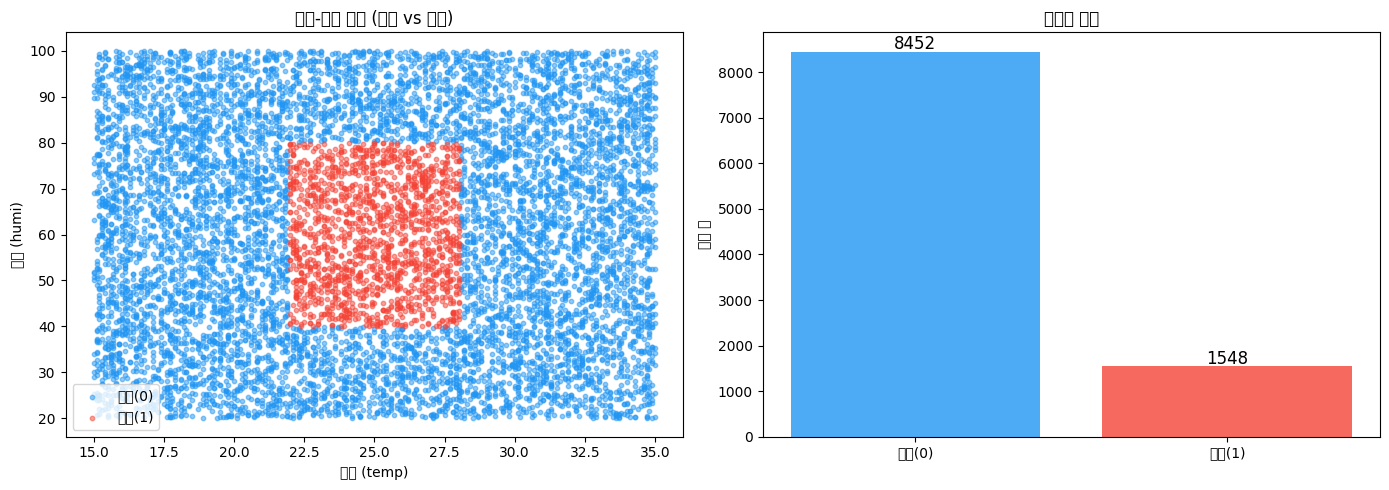

In [ ]:
# 산점도로 데이터 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 왼쪽: 정상/불량 분포
colors = {0: '#2196F3', 1: '#F44336'}
labels_name = {0: '정상(0)', 1: '불량(1)'}
for cls in [0, 1]:
  mask = df['LABEL'] == cls
  axes[0].scatter(
    df[mask]['TEMP'], df[mask]['HUMI'],
    c=colors[cls], label=labels_name[cls],
    alpha=0.5, s=10
  )
axes[0].set_xlabel('온도 (temp)')
axes[0].set_ylabel('습도 (humi)')
axes[0].set_title('온도-습도 분포 (정상 vs 불량)')
axes[0].legend()

# 오른쪽: 레이블 비율 막대 그래프
counts = df['LABEL'].value_counts()
axes[1].bar(['정상(0)', '불량(1)'], counts.values,
            color=['#2196F3', '#F44336'], alpha=0.8)
for i, v in enumerate(counts.values):
  axes[1].text(i, v + 50, str(v), ha='center', fontsize=12)
axes[1].set_title('클래스 분포')
axes[1].set_ylabel('샘플 수')
plt.tight_layout()
plt.show()

In [ ]:
# 특성(X)과 레이블(y) 분리
X = df[['TEMP', 'HUMI']].values
y = df['LABEL'].values

print("X shape:", X.shape) # (샘플 수, 특성 수)
print("y shape:", y.shape)
print("y 고유값:", np.unique(y))

# 학습/테스트 데이터 분리 (8:2)
# stratify=y → 불량 비율을 train/test에서 동일하게 유지
X_train, X_test, y_train, y_test = train_test_split(
  X, y,
  test_size=0.2,
  random_state=42,
  stratify=y # 중요! 클래스 비율 유지
)

print("Train 크기:", X_train.shape)
print("Test  크기:", X_test.shape)
print("\nTrain 불량 비율:", y_train.mean().round(3))
print("Test  불량 비율:", y_test.mean().round(3))

X shape: (10000, 2)
y shape: (10000,)
y 고유값: [0 1]
Train 크기: (8000, 2)
Test  크기: (2000, 2)

Train 불량 비율: 0.155
Test  불량 비율: 0.155


In [ ]:
# 불균형 비율 계산
# scale_pos_weight = 정상 수 / 불량 수
# → 불량에 자동으로 더 높은 가중치 부여 (class_weight='balanced' 와 유사)
n_neg = (y_train == 0).sum() # 정상 수
n_pos = (y_train == 1).sum() # 불량 수
scale = n_neg / n_pos

print(f"정상: {n_neg}건, 불량: {n_pos}건")
print(f"scale_pos_weight = {scale:.2f}")
print(f"→ 불량 샘플에 {scale:.1f}배 가중치 부여")

# XGBoost 모델 정의 및 학습
xgb_model = XGBClassifier(
  n_estimators= 200,
  max_depth = 6,
  learning_rate = 0.1,
  subsample = 0.8,
  colsample_bytree = 0.8,
  scale_pos_weight = scale,
  eval_metric= 'logloss',
  early_stopping_rounds = 10, # ← 여기로 이동
  random_state = 42,
  verbosity = 0
)
# 조기 종료(Early Stopping) 설정
# → 10번 연속 성능 향상 없으면 학습 중단 (과적합 방지)
xgb_model.fit(
  X_train, y_train,
  eval_set=[(X_test, y_test)],
  verbose=False # ← early_stopping_rounds 제거
)
print("학습 완료!")
print(f"실제 사용된 트리 수: {xgb_model.best_iteration + 1}개")


정상: 6762건, 불량: 1238건
scale_pos_weight = 5.46
→ 불량 샘플에 5.5배 가중치 부여
학습 완료!
실제 사용된 트리 수: 200개


In [ ]:
y_pred = xgb_model.predict(X_test) # 클래스 예측 (0 또는 1)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1] # 불량 확률 (0.0 ~ 1.0)

# 지표 계산
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec= recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc= roc_auc_score(y_test, y_pred_prob) # XGBoost는 AUC도 함께 확인

print("=" * 40)
print("[XGBoost 성능 결과]")
print("=" * 40)
print(f"Accuracy  (정확도): {acc:.4f}")
print(f"Precision (정밀도): {prec:.4f}")
print(f"Recall    (재현율): {rec:.4f}")
print(f"F1-score         : {f1:.4f}")
print(f"AUC-ROC          : {auc:.4f}")

print("\n[Confusion Matrix]")
print(confusion_matrix(y_test, y_pred))

print("\n[Classification Report]")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))


[XGBoost 성능 결과]
Accuracy  (정확도): 1.0000
Precision (정밀도): 1.0000
Recall    (재현율): 1.0000
F1-score         : 1.0000
AUC-ROC          : 1.0000

[Confusion Matrix]
[[1690    0]
 [   0  310]]

[Classification Report]
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1690
           1     1.0000    1.0000    1.0000       310

    accuracy                         1.0000      2000
   macro avg     1.0000    1.0000    1.0000      2000
weighted avg     1.0000    1.0000    1.0000      2000



In [ ]:
# 과적합 확인 (Train vs Test 비교)
y_train_pred = xgb_model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print("과적합 확인")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test  Accuracy: {test_acc:.4f}")
print(f"차이:           {abs(train_acc - test_acc):.4f}")

if abs(train_acc - test_acc) < 0.01:
  print("→ 과적합 없음. 좋은 모델입니다.")
elif abs(train_acc - test_acc) < 0.05:
  print("→ 약간의 과적합. 허용 범위입니다.")
else:
  print("→ 과적합 의심. max_depth 줄이기 또는 n_estimators 줄이기 필요.")


과적합 확인
Train Accuracy: 0.9999
Test  Accuracy: 1.0000
차이:           0.0001
→ 과적합 없음. 좋은 모델입니다.


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_3679/2886894555.py:24: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/2886894555.py:24: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/2886894555.py:24: UserW

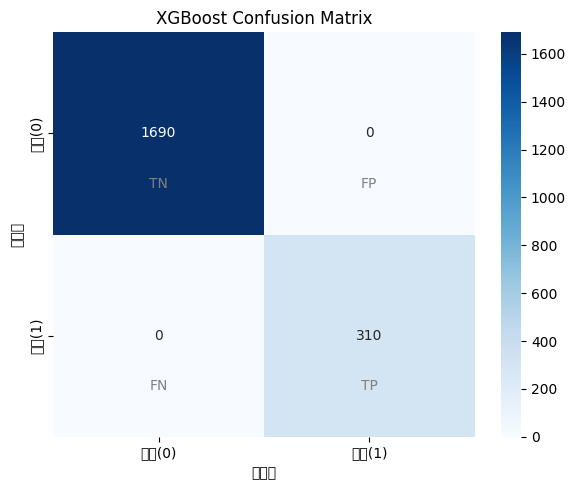

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
  cm, annot=True, fmt='d', cmap='Blues',
  xticklabels=['정상(0)', '불량(1)'],
  yticklabels=['정상(0)', '불량(1)'],
  ax=ax
)
ax.set_xlabel('예측값')
ax.set_ylabel('실제값')
ax.set_title('XGBoost Confusion Matrix')

# 각 셀 의미 표시
labels_cm = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
  for j in range(2):
      ax.text(j+0.5, i+0.75, labels_cm[i][j],
                ha='center', va='center',
                fontsize=10, color='gray')

plt.tight_layout()
plt.show()


/tmp/ipykernel_3679/382074688.py:19: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/382074688.py:19: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/382074688.py:19: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/382074688.py:19: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/382074688.py:19: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/382074688.py:19: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/382074688.py:19: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout

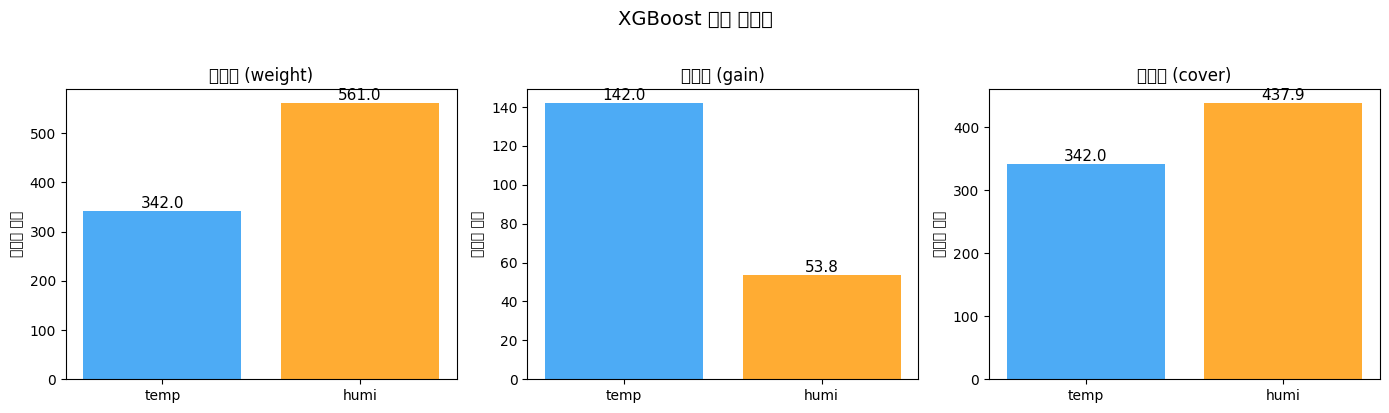


gain 기준 특성 중요도 (클수록 중요):
 temp: 141.99
 humi: 53.78


In [ ]:
# 특성 중요도 3가지 방식으로 비교
# weight  : 해당 변수가 분기에 사용된 횟수
# gain    : 해당 변수가 가져온 평균 성능 향상량 (가장 의미있음)
# cover   : 해당 변수 분기가 커버하는 평균 샘플 수
importance_types = ['weight', 'gain', 'cover']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
feature_names = ['temp', 'humi']
for ax, imp_type in zip(axes, importance_types):
  scores = xgb_model.get_booster().get_score(importance_type=imp_type)
  vals = [scores.get(f'f{i}', 0) for i in range(len(feature_names))]
  colors_bar = ['#2196F3', '#FF9800']
  bars = ax.bar(feature_names, vals, color=colors_bar, alpha=0.8)
  for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01*max(vals),
            f'{v:.1f}', ha='center', fontsize=11)
  ax.set_title(f'중요도 ({imp_type})')
  ax.set_ylabel('중요도 점수')
plt.suptitle('XGBoost 특성 중요도', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
# gain 기준 중요도 출력
print("\ngain 기준 특성 중요도 (클수록 중요):")
scores_gain = xgb_model.get_booster().get_score(importance_type='gain')
for i, fname in enumerate(feature_names):
  val = scores_gain.get(f'f{i}', 0)
  print(f" {fname}: {val:.2f}")


/tmp/ipykernel_3679/2613327261.py:22: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/2613327261.py:22: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/2613327261.py:22: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/2613327261.py:22: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/2613327261.py:22: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/2613327261.py:22: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3679/2613327261.py:22: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.t

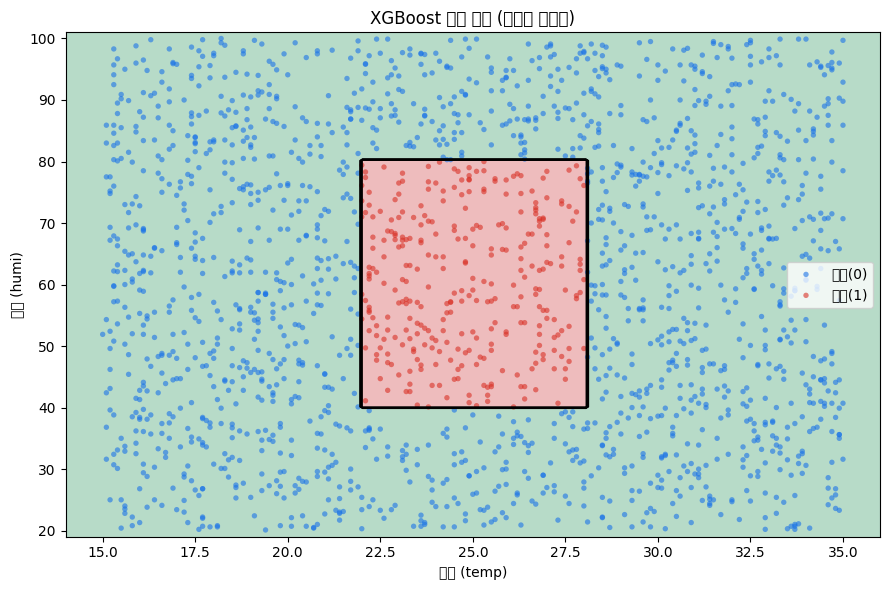

In [ ]:
# 결정 경계 시각화 (temp-humi 공간에서)
xx, yy = np.meshgrid(
  np.linspace(df['TEMP'].min()-1, df['TEMP'].max()+1, 300),
  np.linspace(df['HUMI'].min()-1, df['HUMI'].max()+1, 300)
)
Z = xgb_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 6))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn_r')
ax.contour(xx, yy, Z, colors='black', linewidths=0.8)

for cls, color, label in [(0,'#1a73e8','정상(0)'), (1,'#d93025','불량(1)')]:
  mask = y_test == cls
  ax.scatter(X_test[mask, 0], X_test[mask, 1],
              c=color, label=label, alpha=0.6, s=15, edgecolors='none')

ax.set_xlabel('온도 (temp)')
ax.set_ylabel('습도 (humi)')
ax.set_title('XGBoost 결정 경계 (테스트 데이터)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# GridSearchCV로 최적 파라미터 탐색
param_grid = {
  'n_estimators' : [100, 200, 300],
  'max_depth' : [3, 5, 7],
  'learning_rate' : [0.05, 0.1, 0.2],
  'subsample' : [0.8, 1.0],
}
xgb_base = XGBClassifier(
  scale_pos_weight = scale,
  eval_metric = 'logloss',
  random_state = 42,
  verbosity = 0
)
grid_search = GridSearchCV(
  estimator= xgb_base,
  param_grid = param_grid,
  cv = 5, # 5겹 교차검증
  scoring= 'f1',# 불균형 데이터이므로 F1 기준
  n_jobs = -1,# 병렬 처리
  verbose = 1
)

grid_search.fit(X_train, y_train)

print("\n최적 파라미터:", grid_search.best_params_)
print("최적 F1 점수 :", grid_search.best_score_.round(4))


Fitting 5 folds for each of 54 candidates, totalling 270 fits

최적 파라미터: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}
최적 F1 점수 : 0.9992


In [ ]:
# 최적 파라미터로 최종 평가
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("=" * 40)
print("[최적 XGBoost 최종 결과]")
print("=" * 40)
print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_best, zero_division=0):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_best, zero_division=0):.4f}")
print("\n[Confusion Matrix]")
print(confusion_matrix(y_test, y_pred_best))

[최적 XGBoost 최종 결과]
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

[Confusion Matrix]
[[1690    0]
 [   0  310]]


In [ ]:
import joblib
import json
import numpy as np

# 1. 모델 저장
joblib.dump(xgb_model, 'xgb_model.pkl')

# 2. 학습에 사용한 온도/습도 범위 저장 (랜덤 입력 범위용)
meta = {
  'temp_min': float(df['TEMP'].min()),
  'temp_max': float(df['TEMP'].max()),
  'humi_min': float(df['HUMI'].min()),
  'humi_max': float(df['HUMI'].max()),
}
with open('model_meta.json', 'w') as f:
    json.dump(meta, f)

print("저장 완료!")
print(f"온도 범위: {meta['temp_min']} ~ {meta['temp_max']}")
print(f"습도 범위: {meta['humi_min']} ~ {meta['humi_max']}")

# 3. 구글 드라이브로 다운로드
from google.colab import files
files.download('xgb_model.pkl')
files.download('model_meta.json')


저장 완료!
온도 범위: 15.0 ~ 35.0
습도 범위: 20.0 ~ 100.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>